In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dbfread import DBF
import geopandas as gpd
import folium
import contextily as ctx
import re

plt.rcParams['font.family'] = 'Malgun Gothic' # 윈도우 기준
plt.rcParams['axes.unicode_minus'] = False

### 전역 변수

In [2]:
city = "포항"

### raw 파일 경로

In [3]:
CHILDREN_PROTECT_ZONE_PATH = "raw/Children Protection Zone.csv"
SCHOOL_LOCATION_PATH = "raw/School Location.csv"

LINK_PATH = "raw/NODELINK/MOCT_LINK.dbf"
NODE_PATH = "raw/NODELINK/MOCT_NODE.dbf"

In [4]:
df_protectzone = pd.read_csv(CHILDREN_PROTECT_ZONE_PATH, encoding="utf-8")
df_school = pd.read_csv(SCHOOL_LOCATION_PATH, encoding="utf-8")

df_link = pd.DataFrame(iter(DBF(LINK_PATH, encoding="utf-8")))
df_node = pd.DataFrame(iter(DBF(NODE_PATH, encoding="utf-8")))

In [5]:
df_protectzone.head()

,시설종류,대상시설명,소재지도로명주소,소재지지번주소,위도,경도,관리기관명,관할경찰서명,CCTV설치여부,CCTV설치대수,보호구역도로폭,데이터기준일자
0,유치원,가람유치원,경상북도 포항시 북구 죽도동 양학천로 80,경상북도 포항시 북구 죽도동 333-20,36.020610,129.360181,경상북도 포항시청,포항북부 경찰서,N,0,NaN,2025-12-30
1,유치원,고려 유치원,경상북도 포항시 북구 선착로 54,경상북도 포항시 북구 대신동 1-23,36.049190,129.369398,경상북도 포항시청,포항북부 경찰서,N,0,NaN,2025-12-30
2,유치원,곡강초교병설유치원,경상북도 포항시 북구 양학로 110(학잠동),경상북도 포항시 북구 학잠동 191,36.032314,129.343981,경상북도 포항시청,경상북도 포항북부경찰서,Y,4,10.0,2025-12-30
3,초등학교,곡강초등학교,경상북도 포항시 북구 흥해읍 칠포로 7,경상북도 포항시 북구 흥해읍 용천리 1203,36.130707,129.348800,경상북도 포항시청,포항북부 경찰서,N,0,NaN,2025-12-30
4,초등학교,구룡포 초등학교,경상북도 포항시 남구 구룡포읍 구룡포길 61,경상북도 포항시 남구 구룡포읍 구룡포리 765-1,35.990903,129.551750,경상북도 포항시청,포항남부 경찰서,N,0,NaN,2025-12-30


In [6]:
df_school.head()

,학교ID,학교명,학교급구분,설립일자,설립형태,본교분교구분,운영상태,소재지지번주소,소재지도로명주소,시도교육청코드,시도교육청명,교육지원청코드,교육지원청명,생성일자,변경일자,위도,경도,데이터기준일자
0,B000003362,대전성남초등학교,초등학교,1952-04-15,공립,본교,운영,대전광역시 동구 성남동 193-5,대전광역시 동구 성남로32번길 5,7430000,대전광역시교육청,7441000,대전광역시동부교육지원청,2013-11-29,2025-07-01,36.343944,127.429369,2025-09-22
1,B000025605,일광초등학교,초등학교,2020-03-01,공립,본교,운영,부산광역시 기장군 일광읍 삼성리 774,부산광역시 기장군 일광읍 해빛로 46,7150000,부산광역시교육청,7211000,부산광역시해운대교육지원청,2013-11-29,2025-07-01,35.268118,129.222903,2025-09-22
2,B000009308,성포중학교,중학교,1989-12-22,공립,본교,운영,경기도 안산시 상록구 월피동 459,경기도 안산시 상록구 월피로 73,7530000,경기도교육청,7611000,경기도안산교육지원청,2013-11-29,2025-07-01,37.335528,126.851285,2025-09-22
3,B000003392,서대전초등학교,초등학교,1945-05-15,공립,본교,운영,대전광역시 중구 용두동 27-13,대전광역시 중구 선화로 17,7430000,대전광역시교육청,7441000,대전광역시동부교육지원청,2013-11-29,2025-07-01,36.326809,127.411189,2025-09-22
4,B000002609,상학초등학교,초등학교,2004-03-01,공립,본교,운영,부산광역시 북구 만덕동 570,부산광역시 북구 상학산복길 191,7150000,부산광역시교육청,7201000,부산광역시북부교육지원청,2013-11-29,2025-07-01,35.218679,129.040021,2025-09-22


In [7]:
df_link.head()

,LINK_ID,F_NODE,T_NODE,LANES,ROAD_RANK,ROAD_TYPE,ROAD_NO,ROAD_NAME,ROAD_USE,MULTI_LINK,...,MAX_SPD,REST_VEH,REST_W,REST_H,C-ITS,LENGTH,UPDATEDATE,REMARK,HIST_TYPE,HISTREMARK
0,3920254000,3920171402,3920171505,1,107,000,-,중앙로,0,0,...,50,0,0,0,0,25.906750,20250512,,LINK0003,
1,1950325902,1950129604,1950129603,1,104,000,-,-,0,0,...,30,0,0,0,0,12.807533,20250512,도로명없음,LINK0001,
2,2550168701,2550062203,2550062202,1,107,000,-,중앙로419번길,0,0,...,40,0,0,0,0,12.000377,20250512,,LINK0001,
3,2350594801,2350281001,2350281004,1,107,000,-,화합로,0,0,...,40,0,0,0,0,11.999951,20250512,,LINK0001,
4,3250807600,3250309103,3250701200,1,107,000,-,-,0,0,...,60,0,0,0,0,26.667361,20250512,도로명없음,LINK0003,


In [8]:
df_node.head()

,NODE_ID,NODE_TYPE,NODE_NAME,TURN_P,UPDATEDATE,REMARK,HIST_TYPE,HISTREMARK
0,2360617600,101,동교동 139-3,0,20250512,,NODE0001,
1,2370728800,101,가남읍 태평리 560,0,20250512,,NODE0001,
2,2500630300,101,우두동 1121,0,20250512,,NODE0001,
3,2511046000,101,부론면 단강리 685,0,20250512,,NODE0001,
4,3980357800,101,합천읍 영창리 806,0,20250512,,NODE0001,


In [9]:
df_link.info()

<class 'pandas.DataFrame'>
RangeIndex: 1554105 entries, 0 to 1554104
Data columns (total 21 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   LINK_ID     1554105 non-null  str    
 1   F_NODE      1554105 non-null  str    
 2   T_NODE      1554105 non-null  str    
 3   LANES       1554105 non-null  int64  
 4   ROAD_RANK   1554105 non-null  str    
 5   ROAD_TYPE   1554105 non-null  str    
 6   ROAD_NO     1554105 non-null  str    
 7   ROAD_NAME   1554105 non-null  str    
 8   ROAD_USE    1554105 non-null  str    
 9   MULTI_LINK  1554105 non-null  str    
 10  CONNECT     1554105 non-null  str    
 11  MAX_SPD     1554105 non-null  int64  
 12  REST_VEH    1554105 non-null  str    
 13  REST_W      1554105 non-null  int64  
 14  REST_H      1554105 non-null  int64  
 15  C-ITS       1554105 non-null  str    
 16  LENGTH      1554105 non-null  float64
 17  UPDATEDATE  1554105 non-null  str    
 18  REMARK      1554105 non-null  str

In [10]:
df_node.info()

<class 'pandas.DataFrame'>
RangeIndex: 1177707 entries, 0 to 1177706
Data columns (total 8 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   NODE_ID     1177707 non-null  str  
 1   NODE_TYPE   1177707 non-null  str  
 2   NODE_NAME   1177707 non-null  str  
 3   TURN_P      1177707 non-null  str  
 4   UPDATEDATE  1177707 non-null  str  
 5   REMARK      1177707 non-null  str  
 6   HIST_TYPE   1177707 non-null  str  
 7   HISTREMARK  1177707 non-null  str  
dtypes: str(8)
memory usage: 71.9 MB


In [11]:
df_city_protectzone = df_protectzone[df_protectzone['소재지도로명주소'].str.contains(city, na=False) | 
                                     df_protectzone['소재지지번주소'].str.contains(city, na=False)]

print(f"{city}시 스쿨존 개수: {len(df_city_protectzone)}개")

city_road_names = df_city_protectzone['소재지도로명주소'].dropna().apply(lambda x: x.split()[-1] if x else "")
city_road_names = city_road_names[city_road_names != ""].unique()

df_city_link = df_link[df_link['ROAD_NAME'].isin(city_road_names)]

print(f"포항시 관련 도로(링크) 개수: {len(df_city_link)}개")
print("포항 스쿨존 매칭 성공률 점검을 위한 데이터 확인 완료!")

포항시 스쿨존 개수: 204개
포항시 관련 도로(링크) 개수: 0개
포항 스쿨존 매칭 성공률 점검을 위한 데이터 확인 완료!


In [12]:
# '로' 또는 '길'로 끝나는 단어만 정확히 추출하는 함수
def extract_road_name(address):
    words = str(address).split()
    for word in words:
        # 정규식이나 문자열 끝자리를 이용해 도로명만 필터링
        if word.endswith('로') or word.endswith('길'):
            return word
    return ""

# 수정된 로직으로 도로명 다시 추출
city_road_names = df_city_protectzone['소재지도로명주소'].dropna().apply(extract_road_name)

# 빈 문자열 제거 및 중복 제거
city_road_names = city_road_names[city_road_names != ""].unique()

# 다시 매칭 시도
df_city_link = df_link[df_link['ROAD_NAME'].isin(city_road_names)]

print(f"추출된 {city} 도로명 종류: {len(city_road_names)}개")
print(f"매칭된 {city} 관련 도로(링크) 데이터 개수: {len(df_city_link)}개")

# 잘 뽑혔는지 확인
print("\n추출된 도로명 샘플:", city_road_names[:10])

추출된 포항 도로명 종류: 123개
매칭된 포항 관련 도로(링크) 데이터 개수: 12415개

추출된 도로명 샘플: <StringArray>
['양학천로', '선착로', '양학로', '칠포로', '구룡포길', '구정길', '해병로', '기계로', '기북로', '장량로17번길']
Length: 10, dtype: str


In [13]:
# 포항 스쿨존 도로들의 주요 통계 확인
stats = df_city_link[['LANES', 'MAX_SPD', 'LENGTH']].describe()
print("--- 포항시 스쿨존 관련 도로 통계 ---")
print(stats)

# 차선 수별 도로 개수 확인
lane_counts = df_city_link['LANES'].value_counts().sort_index()
print("\n--- 차선 수별 도로 분포 ---")
print(lane_counts)

--- 포항시 스쿨존 관련 도로 통계 ---
              LANES       MAX_SPD        LENGTH
count  12415.000000  12415.000000  12415.000000
mean       1.638905     52.223923    154.057846
std        0.708086     17.031367    155.366659
min        1.000000     10.000000      0.154699
25%        1.000000     40.000000     17.485228
50%        2.000000     50.000000     90.294530
75%        2.000000     60.000000    271.253992
max        5.000000     80.000000    970.969896

--- 차선 수별 도로 분포 ---
LANES
1    5986
2    5099
3    1161
4     165
5       4
Name: count, dtype: int64


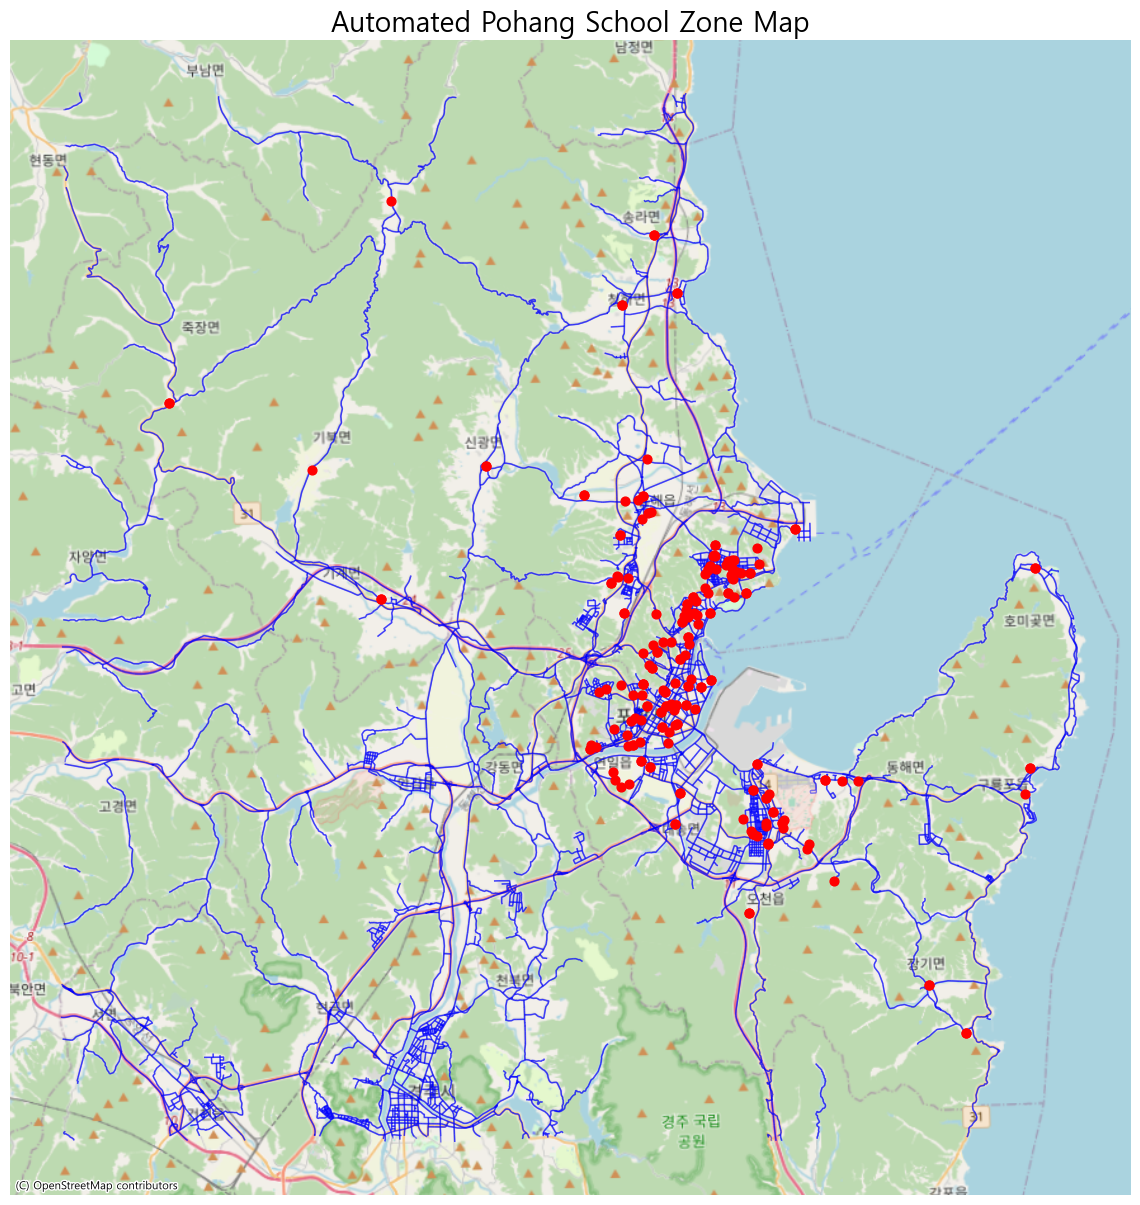

In [24]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

# 1. 스쿨존 데이터를 GeoDataFrame으로 만들고 좌표계 통일 (4326 -> 5186 등)
gdf_school_zones = gpd.GeoDataFrame(
    df_city_protectzone, 
    geometry=gpd.points_from_xy(df_city_protectzone['경도'], df_city_protectzone['위도']),
    crs="EPSG:4326"
).to_crs(gdf_link.crs)

# 2. [핵심] 스쿨존 데이터에서 자동으로 위/경도(X/Y)의 min, max 추출 후 여유(Padding) 추가
minx, miny, maxx, maxy = gdf_school_zones.total_bounds
padding = 5000  # 주변 도로를 더 보기 위해 5km 정도 여유를 줌

# 3. 추출한 범위를 바탕으로 도로 데이터 자르기 (이게 진짜 포항 도로!)
pohang_roads = gdf_link.cx[minx-padding : maxx+padding, miny-padding : maxy+padding]

# 4. 시각화 (이제 어긋날 일이 없습니다)
fig, ax = plt.subplots(figsize=(15, 15))

# 도로망 그리기
pohang_roads.plot(ax=ax, color='blue', linewidth=1, alpha=0.5, label='Pohang Roads')

# 스쿨존 점 찍기
gdf_school_zones.plot(ax=ax, color='red', markersize=40, label='School Zones', zorder=10)

# 배경지도 추가 (데이터 좌표계에 맞춰 자동으로 입힘)
ctx.add_basemap(ax, crs=gdf_link.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)

plt.title("Automated Pohang School Zone Map", fontsize=20)
plt.axis('off')
plt.show()

In [25]:
import geopandas as gpd
import pandas as pd
import folium

# 1. 데이터 로드 (기존에 불러온 데이터 활용)
# gdf_link: 전국 노드링크 (이미 로드되어 있다고 가정)
# df_city_protectzone: 포항시 어린이보호구역 리스트 (이미 로드되어 있다고 가정)

# 2. 스쿨존 데이터를 GeoDataFrame으로 변환 및 좌표계 통일
gdf_school_points = gpd.GeoDataFrame(
    df_city_protectzone, 
    geometry=gpd.points_from_xy(df_city_protectzone['경도'], df_city_protectzone['위도']),
    crs="EPSG:4326"
).to_crs(gdf_link.crs)

# 3. 스쿨존 기반 포항 도로 데이터 동적 추출 (Padding 추가)
minx, miny, maxx, maxy = gdf_school_points.total_bounds
padding = 2000  # 2km 여유
pohang_roads = gdf_link.cx[minx-padding : maxx+padding, miny-padding : maxy+padding]

# 4. [핵심] 정교한 도로 매칭 (Spatial Join)
# 버퍼를 30m로 설정하여 도로 중심선에 인접한 경우만 선택
gdf_school_buffer = gdf_school_points.copy()
gdf_school_buffer['geometry'] = gdf_school_points.buffer(30) 

# 공간 결합 수행
pohang_school_links = gpd.sjoin(pohang_roads, gdf_school_buffer, how='inner', predicate='intersects')

# 외곽의 긴 도로 제거 (300m 이하인 도심 구간만 인정)
if 'LENGTH' in pohang_school_links.columns:
    pohang_school_links = pohang_school_links[pohang_school_links['LENGTH'] <= 300]

# 5. Folium 인터랙티브 지도 생성
# 포항 중심점 자동 계산
center_lat = df_city_protectzone['위도'].mean()
center_lon = df_city_protectzone['경도'].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=13, tiles='cartodbpositron')

# [Layer 1] 일반 도로망 (파란색, 배경용)
# 데이터 양이 많으면 브라우저가 느려질 수 있어 포항 도심 도로만 올립니다.
roads_4326 = pohang_roads.to_crs(epsg=4326)
folium.GeoJson(
    roads_4326,
    name='일반 도로망',
    style_function=lambda x: {'color': '#3186cc', 'weight': 1, 'opacity': 0.3}
).add_to(m)

# [Layer 2] 매칭된 어린이 보호구역 도로 (빨간색, 강조용)
school_links_4326 = pohang_school_links.to_crs(epsg=4326)
folium.GeoJson(
    school_links_4326,
    name='어린이 보호구역 도로',
    style_function=lambda x: {'color': 'red', 'weight': 5, 'opacity': 0.8},
    tooltip="어린이 보호구역 도로 섹션"
).add_to(m)

# [Layer 3] 원래 스쿨존 위치 (검은색 점)
for _, row in df_city_protectzone.iterrows():
    folium.CircleMarker(
        location=[row['위도'], row['경도']],
        radius=2,
        color='black',
        fill=True,
        fill_color='black'
    ).add_to(m)

# 6. 결과 저장 및 확인
m.save("pohang_school_zone_interactive_map.html")
print("지도 생성 완료! 'pohang_school_zone_interactive_map.html' 파일을 열어보세요.")

지도 생성 완료! 'pohang_school_zone_interactive_map.html' 파일을 열어보세요.


In [26]:
import geopandas as gpd
import pandas as pd
import folium

# 1. 데이터 준비 (기존 데이터프레임 활용)
gdf_school_points = gpd.GeoDataFrame(
    df_city_protectzone, 
    geometry=gpd.points_from_xy(df_city_protectzone['경도'], df_city_protectzone['위도']),
    crs="EPSG:4326"
).to_crs(gdf_link.crs)

# 2. [검증 로직 추가] 학교 주소에서 도로명 추출 (예: '양학천로', '칠포로' 등)
# 주소 컬럼에서 '로'나 '길'로 끝나는 단어를 찾아 매칭 확률을 높입니다.
gdf_school_points['road_name_ref'] = gdf_school_points['소재지도로명주소'].str.extract(r'([가-힣]+(?:로|길))')

# 3. [Step 1] 정밀 매칭 (30m 이내) - 이 구간은 거의 확실한 스쿨존
gdf_school_buffer = gdf_school_points.copy()
gdf_school_buffer['geometry'] = gdf_school_points.buffer(30)
precise_matches = gpd.sjoin(pohang_roads, gdf_school_buffer, how='inner', predicate='intersects')

# 4. [Step 2] 찐빠 난 데이터에 대해 '제한적 최단거리 매칭' (거리 60m 제한)
matched_indices = precise_matches['index_right'].unique()
failed_points = gdf_school_points[~gdf_school_points.index.isin(matched_indices)].copy()

# max_distance를 60m로 타이트하게 조여서 엉뚱한 큰길 매칭 방지
nearest_matches = gpd.sjoin_nearest(pohang_roads, failed_points, how='inner', max_distance=60)

# 5. [핵심: 현지인 검증] 도로명 비교 필터링 (선택 사항)
# 매칭된 도로 이름(ROAD_NAME)과 학교 주소의 도로명이 다르면 제거하는 로직을 넣을 수 있습니다.
# (데이터에 'ROAD_NM' 등의 컬럼이 있는지 확인 필요)

# 6. 최종 통합 및 필터링
pohang_school_links = pd.concat([precise_matches, nearest_matches]).drop_duplicates(subset=['geometry'])

# 너무 긴 구간(간선도로 등)은 스쿨존일 확률이 낮으므로 제외
if 'LENGTH' in pohang_school_links.columns:
    pohang_school_links = pohang_school_links[pohang_school_links['LENGTH'] <= 250] # 기준을 더 강화

# 7. 지도 생성 (레이어 구분)
m = folium.Map(location=[center_lat, center_lon], zoom_start=14, tiles='cartodbpositron')

# [Layer] 최종 정제된 스쿨존 도로
folium.GeoJson(
    pohang_school_links.to_crs(epsg=4326),
    style_function=lambda x: {'color': 'red', 'weight': 6, 'opacity': 0.8},
    tooltip="검증된 스쿨존 구간"
).add_to(m)

# [Layer] 원래 학교 위치
for _, row in df_city_protectzone.iterrows():
    folium.CircleMarker([row['위도'], row['경도']], radius=3, color='black', fill=True).add_to(m)

m.save("pohang_refined_school_zone.html")
print(f"최종 정제된 도로 섹션 수: {len(pohang_school_links)}개")

최종 정제된 도로 섹션 수: 233개
